<div style="page-break-before: always;"></div>

In [5]:
#| default_exp ocean_acoustics_part_1

# Ocean Acoustics

Underwater robotics depends on acoustics in a way that terrestrial robotics depends on radio. 

Sound is the primary carrier of information underwater. Electromagnetic waves attenuate quickly in seawater, which makes radio-based positioning and communication ineffective below the surface. As a result, most long-range sensing, localization, and communication tasks in marine robotics rely on acoustics.

This notebook introduces the physical principles of sound propagation in the ocean.

As we go through the course, we will cover:

**Acoustic propagation**
We introduce the fundamental quantities and definitions used to describe sound in water, and we look at how acoustic energy decays with distance through spreading and attenuation. We then connect propagation to oceanographic variability: temperature, salinity, and pressure change over daily and seasonal cycles, and those changes alter sound speed and therefore transmission paths. Where appropriate, we will use simple simulations to make predictions from oceanographic data.

**Acoustic directionality**
We study how directionality arises in underwater acoustics, especially when using arrays. This includes beam patterns, the directivity index, and the idea behind beamforming: shaping sensitivity in space so that we can “listen” or “look” preferentially in a direction.

**Sonar systems**
We connect propagation and directionality to sonar design trade-offs, focusing on the relationship between frequency content, range, and resolution. This is the context in which sonar equations become useful.

**Reflections at the water–bottom interface**
We introduce how the seabed affects propagation through reflection and backscatter. This includes coherent reflections, the Rayleigh coefficient, and what backscatter means for sensing and interpretation.

### Acoustic Propagation in the Ocean

Acoustic propagation describes how pressure disturbances travel through seawater. Unlike propagation in air, the ocean environment introduces strong spatial variability: temperature, salinity, and pressure change with depth, and these variations directly affect sound speed.

To understand sonar systems or acoustic positioning, we first need to understand how waves behave in a homogeneous medium, and then how the ocean modifies that behaviour.

## History of Ocean Acoustics

Ocean acoustics developed alongside navigation, submarine detection, and later scientific oceanography. Many of the mathematical tools used today were motivated by operational needs rather than purely theoretical curiosity.

The early development of sonar systems shaped how acoustic propagation was modeled and measured, and much of that framework remains in use.

Early experiments aimed to measure the speed of sound in water and to understand how signals attenuate over distance.

In 1490, **Leonardo da Vinci** proposed detecting ships by listening to the noise they radiate into water.
_"If you cause your ship to stop and place the head of a long tube in the water and place the other extremity to your ear, you will hear ships at great distances." From Leonardo Da Vinci's Notebook._

The idea is simple and still recognizable today: sound travels efficiently in water, so a sensor coupled to the water can detect distant sources.

The first successful measurements of the speed of sound in water came much later.

In 1826, using the same basic intuition (couple a receiver to the water), **Colladon and Sturm** recorded how fast the sound of a submerged bell traveled across Lake Geneva.

Their Lake Geneva experiment is often illustrated with the “two boats + underwater bell + flash” setup, which is essentially a time-of-flight measurement (see below).

![sound speed measurements](./images/2.ocean-acoustics/3.collodon_sound_speed_measurement.jpeg)

## The First Recorded Attempt to Determine the Speed of Sound in Water

In 1826 on Lake Geneva (Switzerland), physicist **Jean-Daniel Colladon** and mathematician **Charles-François Sturm** carried out what is commonly cited as the first recorded attempt to determine the speed of sound in water.

The measurement strategy was pragmatic. On the first boat they struck an underwater bell and, at the same moment, ignited gunpowder to create a flash. On the second boat, about 10 miles away, observers recorded the delay between the flash (effectively instantaneous at that range) and the arrival of the bell sound. That time delay, together with the known distance, gave an estimate of sound speed.

They also measured the water temperature in the lake (8 °C). At that temperature they obtained a speed of **1435 m/s** in fresh water, within about **3 m/s** of the currently accepted value. Their published report also discussed earlier sea-water measurements made in 1820 near Marseille by **François Sulpice Beudant**.

The point to keep in mind is not just the historical detail. The structure of the experiment—trigger a signal, detect it elsewhere, measure time-of-flight—is the same idea behind modern acoustic ranging and many positioning systems.

World events later pushed ocean acoustics from “measuring constants” toward “understanding the ocean as a propagation medium”.

- World War I and the advent of the submarine drove the development of sonar and of ocean acoustics (acoustical oceanography).

One influential figure was **Maurice Ewing** (see also **Marie Tharp** and the **Lamont Geological Observatory**). Ewing argued that sound could propagate over hundreds—possibly thousands—of kilometers if the source and receiver were placed appropriately.

In 1945 he demonstrated this by propagating sound from a small explosion over **more than 3000 km**, from Eleuthera (Bahamas) to Dakar (West Africa). The map below shows how far these two points are!

The experiment worked because the ocean is not acoustically uniform with depth: the vertical structure can create a waveguide.


![Ewing-experiment](./images/2.ocean-acoustics/3b.sofar.png){width=300px}


Ewing’s long-range propagation took place in what he described as a ubiquitous permanent sound channel in the deep ocean. He called it the **SOFAR channel** (SOund Fixing And Ranging).

One of the early proposed applications was search and rescue. The idea was that a downed-at-sea airman, floating in an inflated rubber boat, could drop small cartridges set to explode near the axis of the SOFAR channel (about 1200 m depth in the North Atlantic). Signals guided by the channel could then be detected far away, enabling ranging and localization.


The figure below (from Applied Underwater Acoustics) shows a sound speed profile with a clear minimum at the depth of the SOFAR channel.

![SOFAR](./images/2.ocean-acoustics/3b.sofar-1.png)





Today, acoustics is used to detect and locate objects and targets; to measure the characteristics of the environment or the velocity and location of moving underwater objects; and to transmit signals.

In robotics, those three roles show up repeatedly: active sonar for perception, acoustic positioning (LBL/USBL, DVL-derived bottom tracking), and acoustic modems for communication. We will expand on all these aspects through the rest of the course
The figure below (from NOAA) is one example of what acoustic sensing can produce: a three-dimensional view derived from echo returns.

![NOAA](./images/2.ocean-acoustics/4.3D_echogram.jpg)



## Understanding Ocean Acoustics

We now shift from history and motivation to the basic physics. The goal is to define the quantities we will keep using: pressure, frequency, wavelength, phase, and then build the simplest wave models before adding ocean-specific complications.

### Sound as a Pressure Wave

Ocean acoustics studies sound and its behaviour in the sea. When an underwater object vibrates, it generates **sound-pressure waves** that alternately compress and decompress water molecules as the disturbance travels. In the simplest picture, the wave radiates away from the source in all directions, like ripples on a pond, except that the disturbance is in pressure rather than surface height.

Those compressions and decompressions can be detected as pressure changes by our ears and by sensors such as a **hydrophone** (an underwater microphone).

The basic components we will use to describe a sound wave are **frequency**, **wavelength**, and **amplitude**.

### Waves

A wave is a self-propagating disturbance in a medium. 
A useful geometric object is the **wavefront**: the locus of points that share the same phase. Intuitively, it is the set of points reached by the perturbation at the same time.

In an **isotropic** medium (same properties in all directions), wavefronts generated by a point source are spherical. If a sound wave emanates from a point source, then at any instant the wavefront is a sphere centred on the source: every point on that sphere has the same phase. As time passes, the sphere expands outward.

Waves carry **energy**, **momentum**, and **information**, but they do not transport matter over long distances.

### Acoustic waves in the ocean

It helps to distinguish the background pressure field from the perturbation created by sound.

**Hydrostatic pressure** is the pressure exerted by the stationary water column at a given depth. It comes from the weight of the fluid above the point:

$$
P = \rho g h
$$

**Acoustic pressure** (sound pressure) is the **local deviation** from the ambient hydrostatic pressure caused by a propagating sound wave.

In seawater, acoustic waves are pressure waves. More specifically, they are **compressional waves**: a disturbance of the local equilibrium pressure that propagates through the medium.

### Compressional waves

**Compressional waves** (also called longitudinal waves or primary P-waves) propagate by creating alternating regions of compression and rarefaction in the medium.

Particles in the medium vibrate **parallel** to the direction of propagation. When one region compresses, it pushes on neighbouring regions; that compression/dilation pattern transmits through the medium and the wave advances.

![P-wave](./images/2.ocean-acoustics/P-wave_animation.gif){width=50%}

Figure from University of Alicante, Spain (https://web.ua.es/en/urs/disclosure/seismic-wave-propagation.html)

A planar P-wave can be pictured as a moving sequence of compressions and rarefactions. The wavefronts are planes, and the motion of the medium is along the direction the wave travels (here you can imagine the Y–Z plane pressing on the particles as the disturbance passes).

#### Some comments

Sound is often illustrated with a sine curve. That picture is a convenient graph of pressure deviation versus time (or versus distance), not a claim that sound “is a sideways wiggle”. In that graph, peaks correspond to compression (higher pressure) and troughs correspond to rarefaction (lower pressure).

The **speed of sound** depends on how easily the medium transmits these compressions. At a microscopic level it is influenced by the distance between molecules and the strength of intermolecular interactions. This is why sound speed tends to increase with density and temperature.

In a gas, molecules are widely spaced with weak intermolecular forces, making the medium highly compressible. This high compressibility results in a relatively slow speed of sound. In contrast, sound travels fastest in solids because their rigid atomic structure provides very high elasticity (bulk modulus). Although solids and liquids are much denser than gases, which typically acts to slow sound down—their massive increase in stiffness far outweighs the effect of density, leading to significantly higher acoustic velocities. We will go deeper into these concepts later in the course.

### Characteristics of Sound Waves

To describe an acoustic pressure wave, we track how pressure varies in **space** and **time**. Sound waves are characterized by **amplitude, intensity, frequency, speed, wavelength, and phase**.

If the pressure perturbation (with respect to equilibrium) is sinusoidal, we can write the pressure variation as:

$$
p(x, t) = A\sin(kx-\omega t + \phi)
$$

where:

- $p(x,t)$ is the pressure deviation from the equilibrium (hydrostatic) pressure at position $x$ and time $t$.
- $A$ is the amplitude (maximum pressure deviation).
- $k$ is the **wave number**, related to wavelength by $k = 2\pi/\lambda$. It sets how rapidly the phase changes in space.
- $x$ is position along the propagation direction.
- $\omega$ is the **angular (radian) frequency**, related to frequency by $\omega = 2\pi f$. It sets how rapidly the phase changes in time.
- $\phi$ is the phase offset.

The argument of the sine has two parts: a term that depends on **space** (through the wave number $k$) and a term that depends on **time** (through the angular frequency $\omega$).

### Angular Frequency

The angular frequency $\omega$ (also called radian frequency) measures how rapidly the wave oscillates in time. It is related to the ordinary frequency $f$ by:

$$
\omega = 2\pi f
$$

Using $c = f\lambda$, we can also write:

$$
\omega = \frac{2\pi c}{\lambda}
$$

In other words, $f$ counts cycles per second, while $\omega$ measures phase rotation in radians per second.

### Wave Number

The wave number $k$ measures how rapidly the wave oscillates in space. It is related to wavelength by:

$$
k = \frac{2\pi}{\lambda}
$$

Using $\omega = ck$, we can also write:

$$
k = \frac{\omega}{c}
$$

Shorter wavelengths correspond to larger $k$: the phase changes more quickly as you move through space.

### Waves in phasor form

For sinusoidal steady-state analysis, it is often convenient to package amplitude and phase into a single complex number (a **phasor**). If we represent our physical wave as a cosine:

$$
y(x,t) = A\cos(kx - \omega t + \phi) 
$$

We can express this as the real part of a complex exponential:

$$
y(x,t) = \operatorname{Re}(Y e^{j(kx - \omega t)})
$$

where $Y$ is the phasor amplitude:

$$
Y = A e^{j\phi}
$$

The benefit is practical: the phasor $Y$ contains the spatial/temporal invariants (amplitude and initial phase), while the term $e^{j(kx-\omega t}$ handles the wave propagation. 
Complex arithmetic makes it significantly easier to calculate interference, reflection coefficients, and superposition. We can always recover the physical signal by taking the real part at the end of the analysis.



In other words, the phasor amplitude $Y$ is a complex number that captures both the amplitude $A$ and the phase information $\phi$ of the wave in a single quantity. The real part of the product $Y e^{j(kx - \omega t)}$ gives the actual physical value of the wave at position $x$ and time $t$.

To obtain the phasor amplitude $Y$, we express the cosine using Euler's inverse formula:

$$y(x,t) = A\cos(kx - \omega t + \phi) = \frac{A}{2}\left(e^{j(kx - \omega t + \phi)} + e^{-j(kx - \omega t + \phi)}\right)$$

We can recover the time-domain function $y(x, t)$ by taking the real part of the positive-frequency rotating vector:

$$y(x,t) = \operatorname{Re}(\underbrace{A e^{j\phi}}_{Y} \cdot e^{j(kx - \omega t)})$$

In this view, $Y$ acts as a complex "container" for magnitude $A$ and phase $\phi$, while $e^{j(kx-\omega t)}$ carries the spatial and temporal evolution. By expressing the wave in phasor form, we can more easily manipulate its properties and use complex arithmetic to analyze interference and superposition without cumbersome trigonometric identities.

Let’s make the space–time interpretation of a travelling sinusoid concrete with a small Python example.

A travelling sine wave changes both in time and in space. If you freeze time and look across space, you see a sinusoid as a function of position. If you freeze position and watch time, you see a sinusoid as a function of time.

In the figure below, we mark a fixed point at $x=2.5$ as a red dot. As the wave propagates, the value at that point varies over time even though the point does not move.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')
# %matplotlib inline

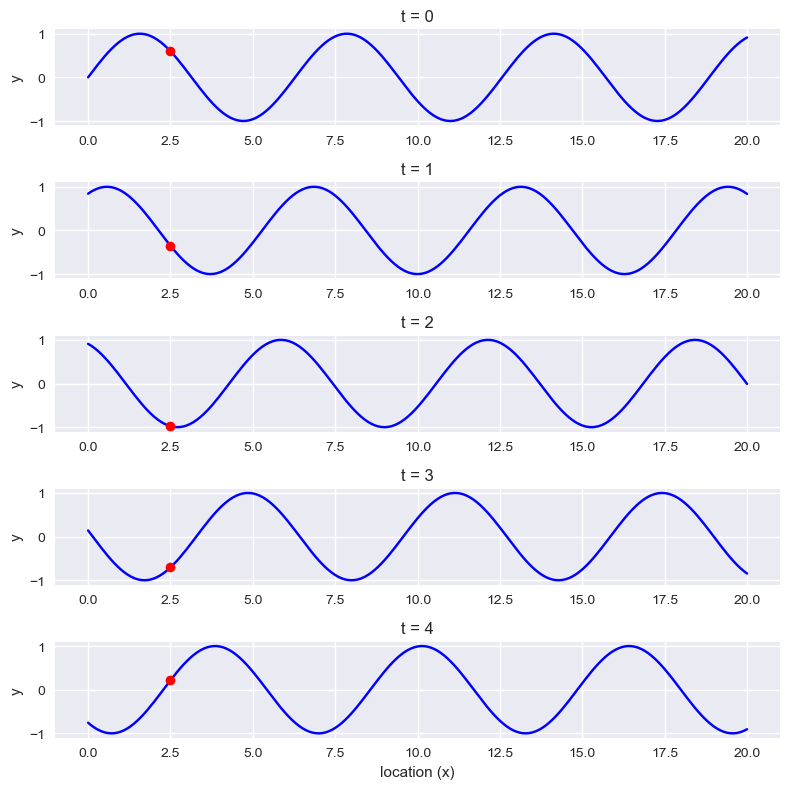

In [2]:
fig = plt.figure(figsize = (8,8))

times = np.arange(5)

n = len(times)
x = np.linspace(0, 20, 201)
y = np.sin(x)

for t in times:
    plt.subplot(n, 1, t+1)
    y = np.sin(x + t)
    plt.plot(x, y, 'b')
    plt.plot(x[25], y [25], 'ro')
    plt.ylim(-1.1, 1.1)
    plt.ylabel('y')
    plt.title(f't = {t}')

plt.xlabel('location (x)')
plt.tight_layout()
plt.show()

You can also look at the same signal the other way around: fix a location $x$ and plot $p(x,t)$ as a function of time. Try this for a few values of $x$ and compare the phase shifts between locations.


### Superposition of waves

When two or more waves exist in the same medium, the disturbance at any point is the **algebraic sum** of the disturbances produced by each wave. In the ideal linear model, waves pass through each other without being permanently altered; what changes is only the instantaneous sum.

Superposition explains interference effects. If two waves of the same frequency and amplitude are **in phase** (crests align with crests, troughs with troughs), their amplitudes add and the result has larger amplitude (**constructive interference**). If they are **out of phase**, they partially or completely cancel (**destructive interference**).

This idea will come back later in array processing and beamforming, where we deliberately exploit constructive/destructive interference across sensors.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [ ]:
# Wave parameters
A = 0.5  # Amplitude
k = 2 * np.pi / 10  # Wave number
omega = 2 * np.pi / 2  # Angular frequency

# Time and space parameters
t = np.linspace(0, 10, 200)  # Time vector
x = np.linspace(0, 20, 400)  # Space vector
X, T = np.meshgrid(x, t)

# Individual wave functions
y1 = A * np.sin(k * X - omega * T)
y2 = A * np.sin(-k * X - omega * T)

# Resulting wave function (superposition of individual waves)
y = y1 + y2

# Plot individual waves and resulting wave
fig, ax = plt.subplots()
ax.set_xlim(0, 20)
ax.set_ylim(-1, 1)
line1, = ax.plot([], [], lw=2, label='Wave 1')
line2, = ax.plot([], [], lw=2, label='Wave 2')
line3, = ax.plot([], [], lw=2, label='Resulting wave')
ax.legend()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    return line1, line2, line3

def animate(i):
    line1.set_data(x, y1[i, :])
    line2.set_data(x, y2[i, :])
    line3.set_data(x, y[i, :])
    return line1, line2, line3

ani = animation.FuncAnimation(fig, animate, frames=len(t), init_func=init, blit=True)
plt.close()  # Prevents duplicate display of animation

The next code cell displays an animation. It works in the online notebook, but it does not render correctly in Quarto/PDF. If you are reading the PDF, you can skip it without losing the thread.

If you are running the notebook, execute the code below to see how two travelling waves superpose in space and time:

```
## Display animation
from IPython.display import HTML
HTML(ani.to_jshtml())
```

### Why this is important for us

In the context of **Underwater Systems**, the principle of superposition is not merely a theoretical exercise; it is the physical mechanism behind how we detect, locate, and communicate with objects underwater.

#### 1. Multipath Propagation
The ocean is a bounded medium. Sound rarely travels along a single path; the receiver sees the **superposition** of multiple arrivals (direct, surface-reflected, and bottom-reflected):

$$p_{total}(t) = \sum_{i=1}^{n} A_i \cos(\omega t + \phi_i)$$

Using phasors, we can determine if these paths will result in a strong signal or a "null" caused by destructive interference. A classic example is the **Lloyd's Mirror effect**, where the surface reflection creates an interference pattern that can significantly alter the received pressure level.

#### 2. Array Processing and Beamforming
Modern sonar systems use an **array of sensors**. By controlling the phase shift of the signal at each sensor, we use constructive interference to "steer" the sensitivity of the array. The total output is the phasor sum:

$$Y_{array} = \sum_{m=0}^{M-1} w_m e^{-j m \Delta \phi}$$

This allows the system to focus on a specific target while using destructive interference to suppress noise coming from other directions.

We will deepen these concepts later in the course. 

### Wave characteristics in one slide

A single travelling wave can be described with a small set of parameters. The figures below show two common ways of “reading” a sinusoid: measuring the period in time, and measuring the wavelength in space.

![Wave Period Amplitude](./images/2.ocean-acoustics/5.wave-period_amplitude.jpg){width=350px}
![Wave Wavelength Amplitude](./images/2.ocean-acoustics/6.wave-wavelength_amplitude.jpg){width=350px}
 

**Amplitude** $A$ is the maximum deviation from the baseline. For acoustic pressure waves, larger amplitude corresponds to larger pressure variation (what we experience as “louder”), and in practice amplitude is often expressed on a decibel scale.

**Period** $T$ is the time required to complete one full cycle. In the figure, it is the time between adjacent peaks (or adjacent troughs).

**Wavelength** $\lambda$ is the spatial analogue of the period: it is the distance between adjacent crests (or troughs) at a fixed time.

### Acoustic Rays

An acoustic ray is a geometric approximation: a line representing the direction along which acoustic energy propagates locally.

Given a wavefront (a surface of equal phase), the associated ray direction is perpendicular to the wavefront at each point. If you draw rays normal to successive wavefronts and connect them, you obtain a **ray path**.

This is the same construction used in optics. We use it here for intuition: it helps explain refraction, shadow zones, and convergence zones without solving the full wave equation. Later we will be explicit about when the ray approximation is valid.